# **MULTIPLE LINEAR REGRESI**

**Import Library**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


**Load Data**

In [10]:
import pandas as pd

# membaca file csv menggunakan pandas
df = pd.read_csv("/content/gdrive/MyDrive/Machine Learning/Pertemuan7/Tugas/data/dataset_satelit (1).csv")

# cetak header data (5 baris data) dari file
df.head()

,No,Longitude,Lattitude,N,P,K,Ca,Mg,Fe,Mn,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
0,1,103.036658,-0.604417,2.64,0.15,0.415,0.51,0.31,119.96,463.23,...,0.0433,0.18183,0.04461,35.74446,35.79744,35.41161,0.22331,0.05479,0.31325,0.07686
1,2,103.037201,-0.604689,2.75,0.17,0.568,0.76,0.58,102.63,493.81,...,0.0465,0.22079,0.04640,35.12096,35.14591,35.41510,0.27116,0.05699,0.38033,0.07993
2,3,103.036359,-0.603012,1.77,0.12,0.339,0.49,0.6,107.37,460.93,...,0.0417,0.18926,0.03992,35.07724,35.07730,35.41135,0.23242,0.04902,0.32604,0.06876
3,4,103.036950,-0.603219,2.30,0.15,0.460,0.74,0.67,96.02,338.17,...,0.0367,0.14769,0.03622,36.08078,36.08469,35.41583,0.18138,0.04448,0.25440,0.06238
4,5,103.036802,-0.601969,2.05,0.14,0.308,0.64,0.72,87.01,384.33,...,0.0361,0.18205,0.03797,32.68855,32.69293,35.41592,0.22359,0.04664,0.31359,0.06541


**Melihat informasi umum data**

In [11]:
# Mencari informasi umum pada data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         594 non-null    int64  
 1   Longitude  594 non-null    float64
 2   Lattitude  594 non-null    float64
 3   N          594 non-null    float64
 4   P          594 non-null    float64
 5   K          593 non-null    float64
 6   Ca         594 non-null    float64
 7   Mg         594 non-null    object 
 8   Fe         594 non-null    float64
 9   Mn         594 non-null    float64
 10  Cu         594 non-null    float64
 11  Zn         594 non-null    float64
 12  B          594 non-null    float64
 13  b12        594 non-null    float64
 14  b11        594 non-null    float64
 15  b9         594 non-null    float64
 16  b8a        594 non-null    float64
 17  b8         594 non-null    float64
 18  b7         594 non-null    float64
 19  b6         594 non-null    float64
 20  b5        

**Menghitung statistik deskriptif pada kolom numeric dengan describe**

In [12]:
df.describe()

,No,Longitude,Lattitude,N,P,K,Ca,Fe,Mn,Cu,...,b1,Sigma_VV,Sigma_VH,plia,lia,iafe,gamma0_vv,gamma0_vh,beta0_vv,beta0_vh
count,594.000000,594.000000,594.000000,594.000000,594.000000,593.000000,594.000000,594.000000,594.000000,594.000000,...,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000
mean,297.500000,106.878644,-1.024933,2.259091,0.141380,0.582175,0.595094,74.613771,308.034697,2.391195,...,0.177291,0.234474,0.102789,28.640422,28.664891,28.609569,0.202587,0.051524,0.269642,0.062320
std,171.617307,4.949840,0.965349,0.395499,0.019782,0.222567,0.366118,55.579655,241.731643,1.580296,...,0.155615,0.070516,0.112310,15.325347,15.380384,15.329170,0.104357,0.012959,0.143728,0.024218
min,1.000000,102.760857,-2.333750,1.140000,0.090000,0.122000,0.050000,21.080000,3.160000,0.090000,...,0.014100,0.115170,0.021460,0.127000,0.098600,0.026000,0.008700,0.016900,0.009300,0.016300
25%,149.250000,102.927811,-2.233338,1.982500,0.130000,0.429000,0.320000,40.705000,124.015000,1.172500,...,0.046925,0.183210,0.039535,31.959745,31.968948,33.685353,0.183085,0.040250,0.244935,0.052772
50%,297.500000,103.581969,-0.602276,2.280000,0.140000,0.549000,0.540000,65.650000,239.445000,2.225000,...,0.072700,0.213385,0.046550,35.067930,35.110415,34.611565,0.233590,0.050415,0.310380,0.068380
75%,445.750000,113.403797,-0.257349,2.570000,0.150000,0.710000,0.790000,87.372500,434.990000,3.357500,...,0.318900,0.262242,0.059190,38.319135,38.441065,39.002760,0.271790,0.060410,0.364505,0.079020
max,594.000000,113.434700,0.069251,3.230000,0.220000,1.489000,2.820000,559.100000,2009.320000,8.170000,...,0.751400,0.512210,0.373000,47.592900,48.014640,39.209330,0.658960,0.122300,0.814170,0.150620


**Pembersihan Data Kolom Mg**

In [14]:
df.columns

Index(['No', 'Longitude', 'Lattitude', 'N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn',
       'Cu', 'Zn', 'B', 'b12', 'b11', 'b9', 'b8a', 'b8', 'b7', 'b6', 'b5',
       'b4', 'b3', 'b2', 'b1', 'Sigma_VV', 'Sigma_VH', 'plia', 'lia', 'iafe',
       'gamma0_vv', 'gamma0_vh', 'beta0_vv', 'beta0_vh'],
      dtype='object')

In [15]:
# ubah kolom Mg ke float
df['Mg'] = pd.to_numeric(df['Mg'], errors='coerce')
# hilangkan baris yang ada missing value
df = df.dropna()

**Memeriksa korelasi antar fitur**

In [16]:
# Cek korelasi antar fitur dengan target (N)
corr = df.corr(numeric_only=True)
corr_y = corr['N'].sort_values(ascending=False)

print("Korelasi tiap fitur terhadap N:\n")
print(corr_y)

Korelasi tiap fitur terhadap N:

N            1.000000
Lattitude    0.742572
P            0.644217
b9           0.537353
b8a          0.530249
b8           0.528981
Sigma_VH     0.506203
Sigma_VV     0.457780
Mn           0.384505
b5           0.376689
Fe           0.337411
b1           0.312135
Zn           0.186262
B            0.123060
b12          0.098317
b2           0.062982
No           0.060062
Ca           0.037590
Cu           0.031330
Mg           0.029797
b4          -0.128815
K           -0.140017
b3          -0.140092
b7          -0.334548
beta0_vv    -0.425721
b11         -0.463486
b6          -0.511929
gamma0_vv   -0.518818
beta0_vh    -0.520465
gamma0_vh   -0.540046
plia        -0.594777
lia         -0.594982
iafe        -0.595197
Longitude   -0.694651
Name: N, dtype: float64


**Korelasi Fitur**

In [17]:
# 🎯 Feature Selection berdasarkan korelasi dengan N
selected_features = [
    'Lattitude', 'Longitude', 'P',
    'b9', 'b8a', 'b8',
    'Sigma_VH', 'plia', 'lia', 'iafe',
    'gamma0_vh', 'beta0_vh', 'gamma0_vv', 'beta0_vv'
]

X = df[selected_features]
y = df['N']

**Heatmap korelasi**

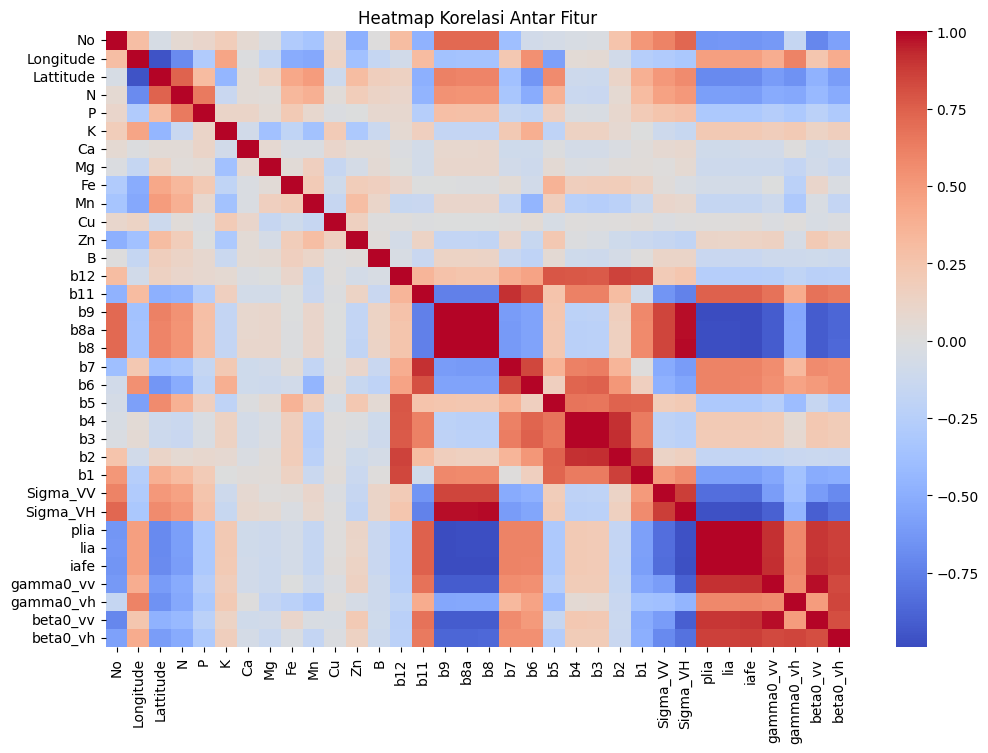

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

**Membagi Data**

In [19]:
# Bagi data: 80% untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Cek bentuk data hasil split
X_train.shape, X_test.shape

((473, 14), (119, 14))

**Training Model Linear Regression**

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Evaluasi Model Linear Regression**

In [21]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Prediksi data testing
y_pred = model.predict(X_test)

# Hitung metrik evaluasi
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Tampilkan hasil
print("R-squared (R²):", r2)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)


R-squared (R²): 0.7365165916073878
Mean Squared Error (MSE): 0.040442044352092026
Root Mean Squared Error (RMSE): 0.2011020744599419


**Analisis Koefisien Model Linear Regression**

In [22]:
coeff = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
})
print(coeff)

        Fitur  Koefisien
0   Lattitude  -0.082641
1   Longitude  -0.061615
2           P   8.999291
3          b9  -0.019937
4         b8a   0.043993
5          b8   0.007062
6    Sigma_VH  -0.298362
7        plia   0.020358
8         lia  -0.024240
9        iafe   0.028471
10  gamma0_vh  -1.854419
11   beta0_vh   1.806138
12  gamma0_vv  -0.361032
13   beta0_vv   0.237013


**Analisis Regresi Linear Menggunakan Statsmodels (OLS Summary)**

In [23]:
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke fitur X
X_sm = sm.add_constant(X)

# Bangun model OLS (Ordinary Least Squares)
model_ols = sm.OLS(y, X_sm).fit()

# Tampilkan ringkasan hasil regresi
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      N   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     123.3
Date:                Sat, 08 Nov 2025   Prob (F-statistic):          5.72e-163
Time:                        16:16:34   Log-Likelihood:                 118.93
No. Observations:                 592   AIC:                            -207.9
Df Residuals:                     577   BIC:                            -142.1
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.8214      2.421      2.818      0.0

**Plot Regresi**

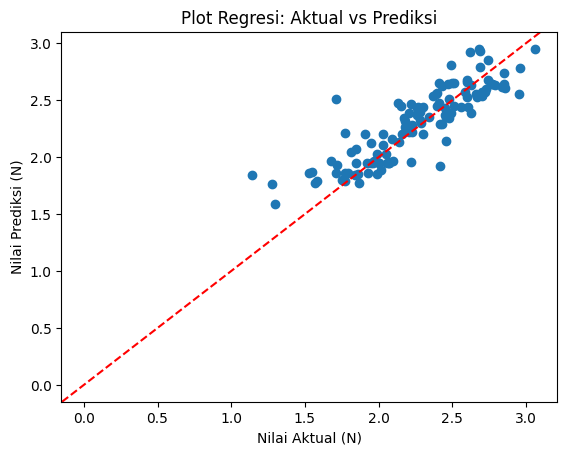

In [25]:
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Aktual (N)")
plt.ylabel("Nilai Prediksi (N)")
plt.title("Plot Regresi: Aktual vs Prediksi")
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.show()

# **Interpretasi Hasil Analisis**
Berdasarkan analisis terhadap dataset yang terdiri dari 549 observasi dan 34 variabel, model yang dibangun menggunakan Regresi Linear (OLS) bertujuan untuk melihat hubungan antara variabel bebas berupa kandungan unsur hara tanah serta informasi dari citra satelit dengan variabel target yang mewakili kondisi tanah. Hasil analisis menunjukkan nilai R-squared sebesar 0.75, yang berarti model mampu menjelaskan sekitar 75% variasi pada data target. Nilai ini mengindikasikan bahwa model memiliki kemampuan prediksi yang cukup baik, meskipun masih ada 25% variasi yang belum terjelaskan dan mungkin dipengaruhi oleh faktor lain di luar variabel yang digunakan.

Dari hasil estimasi koefisien regresi, variabel iafe memiliki p-value sebesar 0.001, lebih kecil dari 0.05, sehingga dapat disimpulkan bahwa variabel ini berpengaruh signifikan terhadap variabel target. Sebaliknya, sebagian besar variabel lainnya memiliki p-value di atas 0.05, yang menunjukkan bahwa pengaruhnya terhadap target tidak signifikan secara statistik.

Evaluasi model juga memperlihatkan nilai Durbin-Watson sebesar 1.527, yang menandakan adanya sedikit autokorelasi positif pada residual. Selain itu, nilai condition number sebesar 2.98 × 10⁵ menunjukkan adanya multikolinearitas yang cukup tinggi antar variabel bebas, terutama di antara variabel yang berasal dari data citra satelit yang memiliki korelasi kuat satu sama lain. Nilai prob(Omnibus) yang sangat kecil juga mengindikasikan bahwa residual model belum sepenuhnya terdistribusi normal.

Secara keseluruhan, model regresi linear ini sudah cukup baik dalam menggambarkan hubungan antara data citra satelit dan kondisi tanah, dengan nilai R-squared yang tinggi dan satu variabel signifikan yang dominan. Namun, model masih bisa ditingkatkan dengan mengurangi variabel yang saling berkorelasi kuat dan menggunakan pendekatan regularisasi seperti Ridge atau Lasso Regression agar model menjadi lebih stabil, lebih akurat, dan lebih memenuhi asumsi klasik regresi.